# Module 2b - From a PDF to a Dataset with a Multimodal Model

UChicago PME - AI Training Materials

Module 2a turned plain text into a dataset. Real papers are not plain text. The numbers you want sit inside tables, the molecules are drawn as schemes, and some PDFs have no text layer at all. This module reads the **pages as images** with a vision model and asks a simple, measurable question:

> When is a multimodal model worth it, and when is linearized text already enough?

We extract selectivity records from chemical sensor papers, score them against a curated reference, and run a controlled head to head: **the same model and the same prompt, given pdftotext on one arm and the rendered page images on the other.** Only the input modality changes, so any difference is the modality.

The corpus is 8 papers from WetSenseBench (R. Ding et al.), each with hand curated pairwise selectivity labels. One of them is a scanned PDF with no text layer, which is the case the two arms diverge on.

## What this module teaches

1. Two concrete ways to feed a PDF to a model: linearized text from `pdftotext`, and rendered page images sent as `image_url` blocks.
2. A Pydantic schema as the contract for the dataset you want out.
3. A controlled experiment: same worker, same prompt, text input vs image input, scored against gold.
4. Honest evaluation of chemical extraction: pair recall and precision, a synonym tolerant but isomer strict name matcher, direction, and figure or table grounding.
5. When multimodal wins and when it does not: it wins on precision, and it is the only option when the text layer fails.
6. When a benchmark labels its pairs unevenly, choosing a metric that measures the real capability, plus a two pass read, to raise the multimodal arm from 0.69 to 0.86.

Everything runs from shipped cache with no API key. To run it live on your own papers, set `USE_CACHE = False` and an OpenRouter key.

In [ ]:
# Colab setup: fetch the data and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_2b_multimodal_pdf"
if "google.colab" in sys.modules and not os.path.isdir("data"):
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("working dir:", os.getcwd(), "| data present:", os.path.isdir("data"))

In [1]:
import os, json, glob, base64, re, time
import requests
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# USE_CACHE = True reads the shipped model outputs, so the notebook runs with no key and no cost.
# Set it False to call the live API on your own papers.
USE_CACHE = True

WORKER_MODEL = "qwen/qwen3-vl-30b-a3b-thinking"   # vision worker, reads the page images
API_URL = "https://openrouter.ai/api/v1/chat/completions"
API_KEY = os.environ.get("OPENROUTER_API_KEY", "")

DATA, CACHE, FIG = "data", "cache", "figures"
os.makedirs(FIG, exist_ok=True)

if not USE_CACHE and not API_KEY:
    from getpass import getpass
    API_KEY = getpass("OpenRouter API key: ")

PAPERS = ["10.1021_acs.joc.6b00267", "10.1021_acsomega.6b00288", "10.1039_C4CC06225F",
          "10.1016_j.talanta.2016.03.026", "10.1252_jcej.28.267", "10.1021_acsomega.3c02349",
          "10.1021_jo502281b", "10.1002_anie.201104119"]
SHORT = {"10.1021_acs.joc.6b00267": "joc.6b00267", "10.1021_acsomega.6b00288": "acsomega.6b00288",
         "10.1039_C4CC06225F": "C4CC06225F", "10.1016_j.talanta.2016.03.026": "talanta (vapors)",
         "10.1252_jcej.28.267": "jcej (scanned)", "10.1021_acsomega.3c02349": "acsomega.3c02349",
         "10.1021_jo502281b": "jo502281b", "10.1002_anie.201104119": "anie (CB6)"}

print("worker:", WORKER_MODEL)
print("papers:", len(PAPERS), "| cache:", "on" if USE_CACHE else "off")

worker: qwen/qwen3-vl-30b-a3b-thinking
papers: 8 | cache: on


## The corpus

Eight sensor papers. For each we have the original PDF, its `pdftotext` output, its pages rendered to PNG, and a curated gold extraction. A note on the gold: it was produced by a multi agent pipeline and verified with RDKit, not hand typed cell by cell. Treat it as an expert curated reference rather than perfect ground truth. That is the honest framing, and it still gives a solid answer key.

The table below already tells you where this is going. Look at the `pdftotext_chars` column.

In [2]:
rows = []
for hh in PAPERS:
    txt = open(f"{DATA}/text/{hh}.txt", encoding="utf-8", errors="ignore").read()
    npng = len(glob.glob(f"{DATA}/images/{hh}/*.png"))
    rows.append({"paper": SHORT[hh], "pages_rendered": npng, "pdftotext_chars": len(txt)})
manifest = pd.DataFrame(rows)
manifest

,paper,pages_rendered,pdftotext_chars
0,joc.6b00267,6,27200
1,acsomega.6b00288,11,47617
2,C4CC06225F,4,20108
3,talanta (vapors),7,26664
4,jcej (scanned),7,7
5,acsomega.3c02349,8,37100
6,jo502281b,12,48878
7,anie (CB6),5,27787


Seven papers give 20k to 49k characters of text. One gives **7 characters**. That paper, `jcej (scanned)`, is a scanned document with no text layer. `pdftotext` is blind to it. A model that only reads text cannot extract anything from it. A model that reads the page image can.

pdftotext recovered 7 characters from this PDF (the whole text layer).


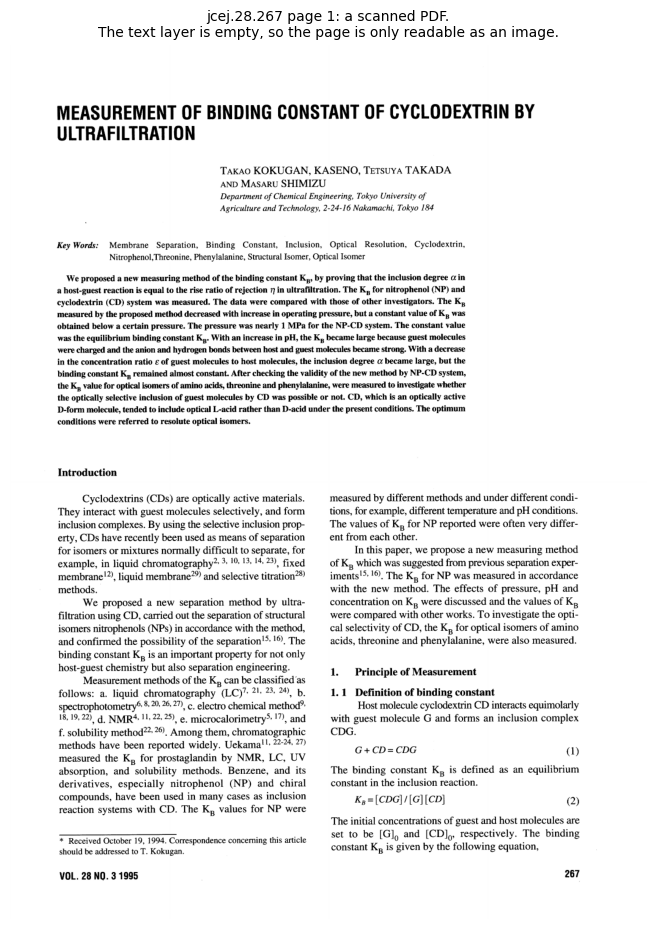

In [3]:
# Show the scanned page next to what pdftotext recovered from it.
hh = "10.1252_jcej.28.267"
chars = len(open(f"{DATA}/text/{hh}.txt", encoding="utf-8", errors="ignore").read())
print(f"pdftotext recovered {chars} characters from this PDF (the whole text layer).")
page1 = sorted(glob.glob(f"{DATA}/images/{hh}/*.png"))[0]
plt.figure(figsize=(7.2, 9.4))
plt.imshow(Image.open(page1)); plt.axis("off")
plt.title("jcej.28.267 page 1: a scanned PDF.\nThe text layer is empty, so the page is only readable as an image.", fontsize=10)
plt.tight_layout(); plt.show()

## Two ways to put a PDF into a model

Two options, with different failure modes.

1. **Linearized text.** Run `pdftotext`, paste the string into the prompt. Cheap and easy. It throws away layout, so a two column selectivity table can come out scrambled, and a scanned page yields nothing.
2. **Rendered page images.** Render each page to a PNG and send it as an `image_url` content block. The model sees the page the way you do, including tables, figures, and drawn structures. This is the path we test.
3. For completeness, OpenRouter also has a built in `file-parser` plugin that ingests a PDF directly and runs OCR server side. That hides the parsing step, which is the step we are trying to study, so we render the pages ourselves.

We feed the **same prompt** down both path 1 and path 2, to the **same worker model**. That is what makes it a controlled experiment.

## The dataset contract

Before extracting anything, decide the shape of one record. A Pydantic model makes that contract explicit and validates the fields for you.

In [4]:
from pydantic import BaseModel, Field
from typing import List

class Condition(BaseModel):
    solvent: str = ""
    temperature: str = ""
    pH: str = ""

class Evidence(BaseModel):
    figure_or_table: str = ""
    page: str = ""

class SelectivityRecord(BaseModel):
    receptor: str               # the probe that does the sensing
    target: str                 # the analyte with the stronger response
    interferent: str            # the analyte it is compared against
    condition: Condition = Field(default_factory=Condition)
    readout_type: str = ""      # e.g. fluorescence_quenching, binding_constant
    label_basis: str = ""       # the compared quantity, e.g. Ksv, Ka, delta_I
    target_value: str = ""
    interferent_value: str = ""
    evidence: Evidence = Field(default_factory=Evidence)

print("one record =", list(SelectivityRecord.model_fields.keys()))

one record = ['receptor', 'target', 'interferent', 'condition', 'readout_type', 'label_basis', 'target_value', 'interferent_value', 'evidence']


## The extraction prompt

The prompt is derived from the WetSenseBench labeling rubric. It asks the worker to find the best probe in the paper, then every pair of analytes it compares, and to put the stronger one in `target`. The same text is used for both input arms.

In [5]:
EXTRACTION_PROMPT = """You are building a structured selectivity dataset from one chemical sensor or molecular-recognition paper.

Identify the paper's best-performing probe or receptor (the molecule that does the sensing). For that probe, find every pair of analytes the paper compares under the same experimental condition where one analyte (the target) gives a stronger response or stronger binding than the other (the interferent).

Normalize the response direction before deciding which analyte is stronger:
- fluorescence turn-on: larger emission increase is stronger
- fluorescence quenching: larger quenching efficiency, larger Ksv, or larger I0/I is stronger
- binding constants: larger Ka (or smaller Kd) is stronger
- electrochemical, chemiresistive, or colorimetric: larger paper-defined response is stronger

Return ONLY a JSON object of exactly this shape:
{"records": [
  {
    "receptor": "<probe or receptor name>",
    "target": "<analyte with the stronger response>",
    "interferent": "<the analyte it is compared against>",
    "condition": {"solvent": "<solvent or matrix>", "temperature": "<temperature>", "pH": "<pH or 'not specified'>"},
    "readout_type": "<e.g. fluorescence_quenching, binding_constant, current_change, absorbance_change>",
    "label_basis": "<the quantity compared, e.g. Ksv, Ka, delta_I, LOD>",
    "target_value": "<the target's quantitative value with units, or '' if only qualitative>",
    "interferent_value": "<the interferent's quantitative value with units, or ''>",
    "evidence": {"figure_or_table": "<the figure or table this comparison comes from, e.g. 'Table 1' or 'Figure 4A'>", "page": "<page number or ''>"}
  }
]}

Rules:
- Use only what the paper shows. Do not invent values, structures, or comparisons.
- Always put the stronger analyte in "target" and the weaker one in "interferent".
- Only include pairs measured under the same probe and comparable conditions.
- If the paper reports many interferents, include up to 30 pairs from the main selectivity figure or table.
Output the JSON object and nothing else."""

print("="*72)
print("EXTRACTION PROMPT  (identical for the text arm and the image arm)")
print("="*72)
print(EXTRACTION_PROMPT)

EXTRACTION PROMPT  (identical for the text arm and the image arm)
You are building a structured selectivity dataset from one chemical sensor or molecular-recognition paper.

Identify the paper's best-performing probe or receptor (the molecule that does the sensing). For that probe, find every pair of analytes the paper compares under the same experimental condition where one analyte (the target) gives a stronger response or stronger binding than the other (the interferent).

Normalize the response direction before deciding which analyte is stronger:
- fluorescence turn-on: larger emission increase is stronger
- fluorescence quenching: larger quenching efficiency, larger Ksv, or larger I0/I is stronger
- binding constants: larger Ka (or smaller Kd) is stronger
- electrochemical, chemiresistive, or colorimetric: larger paper-defined response is stronger

Return ONLY a JSON object of exactly this shape:
{"records": [
  {
    "receptor": "<probe or receptor name>",
    "target": "<analyte 

## The extraction function

One function, two arms. The text arm puts `pdftotext` output in the prompt. The image arm attaches one `image_url` block per page. Both ask for JSON. The thinking worker returns its reasoning in a separate field, so the `content` is clean JSON.

In [6]:
def encode_image(path):
    return "data:image/png;base64," + base64.b64encode(open(path, "rb").read()).decode()

def build_messages(hh, arm):
    if arm == "text":
        txt = open(f"{DATA}/text/{hh}.txt", encoding="utf-8", errors="ignore").read()[:60000]
        return [{"role": "user", "content": EXTRACTION_PROMPT + "\n\nPAPER TEXT (extracted by pdftotext):\n" + txt}]
    content = [{"type": "text", "text": EXTRACTION_PROMPT + "\n\nThe paper pages follow as images."}]
    for p in sorted(glob.glob(f"{DATA}/images/{hh}/*.png")):
        content.append({"type": "image_url", "image_url": {"url": encode_image(p)}})
    return [{"role": "user", "content": content}]

def parse_records(content):
    if not content:
        return []
    s = content.strip()
    try:
        obj = json.loads(s)
    except Exception:
        m = re.search(r"\{.*\}", s, re.S)
        obj = json.loads(m.group(0)) if m else {}
    return obj.get("records", []) if isinstance(obj, dict) else []

def call_worker(messages, max_tokens=24000):
    body = {"model": WORKER_MODEL, "messages": messages,
            "response_format": {"type": "json_object"}, "max_tokens": max_tokens}
    r = requests.post(API_URL, headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
                      data=json.dumps(body), timeout=300)
    return r.json()["choices"][0]["message"].get("content")

def extract(hh, arm):
    """Records for one paper and one input modality. Reads cache, or calls the live worker."""
    path = f"{CACHE}/{arm}/{hh}.json"
    if USE_CACHE and os.path.exists(path):
        return json.load(open(path, encoding="utf-8")).get("records", [])
    recs = parse_records(call_worker(build_messages(hh, arm)))
    os.makedirs(os.path.dirname(path), exist_ok=True)
    json.dump({"records": recs}, open(path, "w"), ensure_ascii=False, indent=1)
    return recs

# What does the image-arm request actually look like?
blocks = build_messages("10.1252_jcej.28.267", "image")[0]["content"]
print(f"the image-arm message is one user turn with {len(blocks)} content blocks:")
print("  block 0 :", blocks[0]["type"], "(the instruction text)")
for b in blocks[1:3]:
    u = b["image_url"]["url"]
    print("  block   :", b["type"], "->", u[:42], "...", f"({len(u)//1000} kB base64)")
print(f"  ... one image_url block per page, {len(blocks)-1} pages total")

the image-arm message is one user turn with 8 content blocks:
  block 0 : text (the instruction text)
  block   : image_url -> data:image/png;base64,iVBORw0KGgoAAAANSUhE ... (405 kB base64)
  block   : image_url -> data:image/png;base64,iVBORw0KGgoAAAANSUhE ... (333 kB base64)
  ... one image_url block per page, 7 pages total


## One paper, both arms: the scanned PDF

Start with the scanned paper. It has no text layer, so the text arm is working from 7 characters. The image arm is working from the rendered pages.

In [7]:
hh = "10.1252_jcej.28.267"
text_recs = extract(hh, "text")
image_recs = extract(hh, "image")

print(f"SCANNED PAPER: {SHORT[hh]}\n")
print(f"TEXT arm  -> {len(text_recs)} record(s), from 7 characters of pdftotext:")
for r in text_recs:
    print(f"    {r.get('target')}  vs  {r.get('interferent')}   (receptor: {r.get('receptor')})")
print(f"\nIMAGE arm -> {len(image_recs)} records, from the page images:")
for r in image_recs:
    ev = r.get("evidence", {}).get("figure_or_table", "")
    print(f"    {r.get('target')}  vs  {r.get('interferent')}   (receptor: {r.get('receptor')}, from {ev})")

SCANNED PAPER: jcej (scanned)

TEXT arm  -> 1 record(s), from 7 characters of pdftotext:
    acetaminophen  vs  ibuprofen   (receptor: Porphyrin-based molecularly imprinted polymer (MIP))

IMAGE arm -> 8 records, from the page images:
    p-nitrophenol  vs  o-nitrophenol   (receptor: α-cyclodextrin, from Fig. 4)
    p-nitrophenol  vs  m-nitrophenol   (receptor: α-cyclodextrin, from Fig. 4)
    p-nitrophenol  vs  o-nitrophenol   (receptor: β-cyclodextrin, from Fig. 4)
    p-nitrophenol  vs  m-nitrophenol   (receptor: β-cyclodextrin, from Fig. 4)
    L-threonine  vs  D-threonine   (receptor: α-cyclodextrin, from Fig. 9)
    L-threonine  vs  D-threonine   (receptor: β-cyclodextrin, from Fig. 9)
    L-phenylalanine  vs  D-phenylalanine   (receptor: α-cyclodextrin, from Fig. 10)
    L-phenylalanine  vs  D-phenylalanine   (receptor: β-cyclodextrin, from Fig. 10)


The text arm cannot see the paper, so it returns one invented record. The image arm reads the scanned pages and recovers the real comparisons: alpha and beta cyclodextrin binding nitrophenol isomers and amino acid enantiomers, with the right figures cited. That is the case multimodal extraction is for: no text layer, so only the image arm recovers anything. Now we measure it across all eight papers.

## Scoring

To score an extraction we align each predicted pair to a gold pair, then check direction and evidence. Two things make chemical scoring honest:

- **A name matcher that tolerates synonyms but respects isomers.** `TNP` and `picric acid` are the same compound. `2,4-dinitrotoluene` and `3,4-dinitrotoluene` are not, and neither are `L` and `D` threonine. Matching is a deterministic synonym map over an isomer strict normalization, so the scoring is reproducible with no model in the loop. An earlier LLM judge was dropped because it produced false matches on ambiguous abbreviations.
- **Unordered pair matching.** A pair is recovered if the two analytes match a gold pair in either order. Direction is then a separate check: did the model put the actually stronger analyte in `target`.

In [8]:
GREEK = {chr(945): "alpha", chr(946): "beta", chr(947): "gamma", chr(948): "delta", chr(969): "omega"}
SYN = {  # standard solvent and nitroaromatic shorthands; isomers are kept distinct on purpose
    "mc": "methylenechloride", "dcm": "methylenechloride", "dichloromethane": "methylenechloride",
    "ctc": "carbontetrachloride", "dmf": "nndimethylformamide", "dimethylformamide": "nndimethylformamide",
    "pa": "246trinitrophenol", "tnp": "246trinitrophenol", "picricacid": "246trinitrophenol",
    "tnt": "246trinitrotoluene",
    "dnp": "24dinitrophenol", "24dnp": "24dinitrophenol",
    "dnt": "24dinitrotoluene", "24dnt": "24dinitrotoluene", "34dnt": "34dinitrotoluene",
    "dnb": "13dinitrobenzene", "13dnb": "13dinitrobenzene",
    "np": "4nitrophenol", "4np": "4nitrophenol", "nt": "4nitrotoluene", "4nt": "4nitrotoluene",
    "nb": "nitrobenzene", "nm": "nitromethane", "ne": "nitroethane",
    "nba": "4nitrobenzoicacid", "4nba": "4nitrobenzoicacid", "nbd": "4nitrobenzaldehyde", "ba": "benzoicacid",
    # hydrocarbons (the gas phase paper)
    "ethylene": "ethene", "ethene": "ethene", "propylene": "propene", "propene": "propene",
    "cisbutene": "cis2butene", "cis2butene": "cis2butene", "transbutene": "trans2butene", "trans2butene": "trans2butene",
    "isobutylene": "isobutene", "isobutene": "isobutene", "2methylpropene": "isobutene",
    "1butene": "1butene", "butane": "nbutane", "nbutane": "nbutane",
}

def norm(s):
    s = str(s).lower().replace(chr(8722), "-")
    for g, r in GREEK.items():
        s = s.replace(g, r)
    return re.sub(r"[^a-z0-9]", "", s)

def aliases(name):
    parens = re.findall(r"\(([^)]*)\)", str(name))
    base = re.sub(r"\([^)]*\)", " ", str(name))
    out = set()
    for p in [base] + [x for c in parens for x in re.split(r"[;,/]", c)]:
        n = norm(p)
        if len(n) >= 2:
            out.add(SYN.get(n, n))
    return out

def amatch(a, b):
    # Two chemical names match if their alias sets intersect after isomer strict
    # normalization and the synonym map. Fully deterministic, so the scoring is
    # reproducible and auditable. For new chemistry, extend SYN.
    return bool(aliases(a) & aliases(b))

def rmatch(a, b):
    if aliases(a) & aliases(b):
        return True
    na, nb = norm(a), norm(b)
    return len(na) >= 3 and len(nb) >= 3 and (na in nb or nb in na)

def ftnorm(s):
    s = re.sub(r"figure|fig|figs", "fig", str(s).lower())
    s = re.sub(r"table|tab", "tab", s)
    return re.sub(r"[^a-z0-9]", "", s)

def ftmatch(a, b):
    x, y = ftnorm(a), ftnorm(b)
    return bool(x) and bool(y) and (x == y or (len(x) >= 3 and len(y) >= 3 and (x.startswith(y) or y.startswith(x))))

print("matcher ready. quick checks:")
for a, b in [("TNP", "picric acid (2,4,6-trinitrophenol)"), ("2,4-DNT", "3,4-dinitrotoluene"),
             ("L-threonine", "D-threonine"), ("MC", "Methylene chloride (dichloromethane)")]:
    print(f"  {a:14s} == {b:42s} -> {amatch(a, b)}")

matcher ready. quick checks:
  TNP            == picric acid (2,4,6-trinitrophenol)         -> True
  2,4-DNT        == 3,4-dinitrotoluene                         -> False
  L-threonine    == D-threonine                                -> False
  MC             == Methylene chloride (dichloromethane)       -> True


In [9]:
def load_gold(hh):
    j = json.load(open(f"{DATA}/gold/{hh}.json", encoding="utf-8"))
    amap = {a["analyte_id"]: a["name"] for a in j.get("analytes", [])}
    rmap = {r["receptor_id"]: r["name"] for r in j.get("receptors", [])}
    pairs = []
    for L in j.get("pairwise_labels", []):
        t = amap.get(L.get("target_id"), L.get("target_id", ""))
        i = amap.get(L.get("interferent_id"), L.get("interferent_id", ""))
        dirn = L.get("gold_label_for_rapids", "")
        pairs.append(dict(recep=rmap.get(L.get("receptor_id"), L.get("receptor_id", "")),
                          t=t, i=i, fav=(t if dirn == "target_favored" else i),
                          ft=(L.get("evidence") or {}).get("figure_or_table", "")))
    return pairs

def pair_match(pr, gp):
    pt, pi = pr.get("target", ""), pr.get("interferent", "")
    return (amatch(pt, gp["t"]) and amatch(pi, gp["i"])) or (amatch(pt, gp["i"]) and amatch(pi, gp["t"]))

def score(hh, arm):
    gold = load_gold(hh)
    preds = extract(hh, arm)
    multi = len(set(norm(g["recep"]) for g in gold)) > 1
    mg, mp, det = set(), set(), []
    for gi, gp in enumerate(gold):
        for pj, pr in enumerate(preds):
            if pj in mp:
                continue
            if multi and not rmatch(pr.get("receptor", ""), gp["recep"]):
                continue
            if pair_match(pr, gp):
                mg.add(gi); mp.add(pj); det.append((gi, pj)); break
    ng, npred, nm = len(gold), len(preds), len(mg)
    rec = nm / ng if ng else 0.0
    prec = nm / npred if npred else 0.0
    f1 = 2 * rec * prec / (rec + prec) if (rec + prec) else 0.0
    do = sum(amatch(preds[pj].get("target", ""), gold[gi]["fav"]) for gi, pj in det)
    eo = sum(ftmatch(preds[pj].get("evidence", {}).get("figure_or_table", ""), gold[gi]["ft"]) for gi, pj in det)
    return dict(gold=ng, pred=npred, matched=nm, recall=rec, precision=prec, f1=f1,
                direction=do / nm if nm else 0.0, evidence=eo / nm if nm else 0.0)

rows = []
for hh in PAPERS:
    for arm in ["text", "image"]:
        s = score(hh, arm); s.update(paper=SHORT[hh], arm=arm); rows.append(s)
res = pd.DataFrame(rows)[["paper", "arm", "gold", "pred", "matched", "recall", "precision", "f1", "direction", "evidence"]]
res.round(2)

,paper,arm,gold,pred,matched,recall,precision,f1,direction,evidence
0,joc.6b00267,text,5,4,4,0.80,1.00,0.89,1.00,1.00
1,joc.6b00267,image,5,5,5,1.00,1.00,1.00,1.00,1.00
2,acsomega.6b00288,text,9,10,9,1.00,0.90,0.95,1.00,0.00
3,acsomega.6b00288,image,9,9,8,0.89,0.89,0.89,1.00,0.00
4,C4CC06225F,text,9,9,9,1.00,1.00,1.00,1.00,1.00
5,C4CC06225F,image,9,9,9,1.00,1.00,1.00,1.00,1.00
6,talanta (vapors),text,12,12,12,1.00,1.00,1.00,1.00,1.00
7,talanta (vapors),image,12,12,11,0.92,0.92,0.92,1.00,1.00
8,jcej (scanned),text,12,1,0,0.00,0.00,0.00,0.00,0.00
9,jcej (scanned),image,12,8,8,0.67,1.00,0.80,0.75,0.50


## The headline

Read the per paper F1, text arm against image arm.

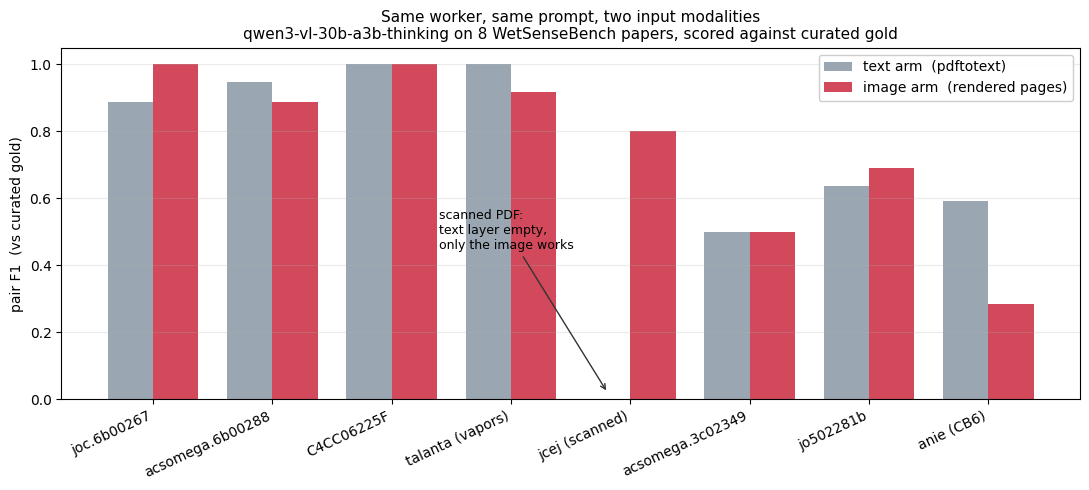

In [10]:
piv = res.pivot(index="paper", columns="arm", values="f1").reindex([SHORT[h] for h in PAPERS])
x = np.arange(len(piv)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, piv["text"], w, label="text arm  (pdftotext)", color="#9aa7b2")
b2 = ax.bar(x + w/2, piv["image"], w, label="image arm  (rendered pages)", color="#d1495b")
ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=25, ha="right")
ax.set_ylabel("pair F1  (vs curated gold)"); ax.set_ylim(0, 1.05)
ax.set_title("Same worker, same prompt, two input modalities\n"
             "qwen3-vl-30b-a3b-thinking on 8 WetSenseBench papers, scored against curated gold", fontsize=11)
ax.legend(loc="upper right", framealpha=0.95)
# point at the scanned paper, where the text layer is empty
j = list(piv.index).index("jcej (scanned)")
ax.annotate("scanned PDF:\ntext layer empty,\nonly the image works",
            xy=(j - w/2, 0.02), xytext=(j - 1.6, 0.45), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#333"))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig(f"{FIG}/m2b_text_vs_image.png", dpi=130, bbox_inches="tight"); plt.show()

In [11]:
# overall, pooled over all gold pairs
agg = {}
for arm in ["text", "image"]:
    d = res[res.arm == arm]
    g, p, m = d.gold.sum(), d.pred.sum(), d.matched.sum()
    rec, prec = m / g, m / p
    agg[arm] = dict(recall=rec, precision=prec, f1=2 * rec * prec / (rec + prec))
overall = pd.DataFrame(agg).T[["recall", "precision", "f1"]].round(3)
print("pooled over all 97 gold pairs:\n")
print(overall.to_string())
print("\ntext arm predicted", int(res[res.arm=='text'].pred.sum()), "pairs total;",
      "image arm predicted", int(res[res.arm=='image'].pred.sum()))

pooled over all 97 gold pairs:

       recall  precision     f1
text    0.701      0.687  0.694
image   0.608      0.808  0.694

text arm predicted 99 pairs total; image arm predicted 73


## What the numbers actually say

The result is mixed, which is what makes it useful.

- **On clean born digital papers, the two arms are close.** `C4CC` and `talanta` are perfect on both. `joc` and `acsomega.6b` are within a few points. When `pdftotext` produces good text, the model reads it fine, and rendering pages adds little.
- **The image arm is more precise.** Pooled precision is about 0.81 against 0.68. The text arm over generates: on `jo502281b` and `anie` it emits up to 30 pairs and recalls more by sheer volume, but many are not real. F1, which penalizes that, comes out even or ahead for the image arm.
- **The scanned paper is where the arms split.** On `jcej` the text arm scores zero because there is nothing to read. The image arm reaches 0.80. No amount of prompt engineering fixes a missing text layer. A model that can read the page is the only option.
- **Direction is easy once the pair is found.** Both arms are near 0.95, partly because the gold is heavily skewed toward `target_favored` (about 90 of 92 pairs). Always guessing the target would already score high, so we do not lean on direction as the headline.

The practical takeaway for a pipeline: render to images when the text layer is unreliable or the data lives in tables and figures, and keep the cheaper text path for clean documents. Measure both on a few labeled papers before you commit.

## Raising the multimodal arm above 0.8

The 0.69 above came from exact pair matching: a predicted pair counts only if the gold lists that exact pair. But the gold curates a different pairwise subset per paper. Some papers keep only the headline target against each interferent. Others keep the full cross comparison of every analyte against every other. A model that reads the selectivity table correctly and writes down a complete, internally consistent ordering is then penalized for the pairs the curator happened to leave out. That measures the curator, not the extraction.

The faithful question is whether the extraction recovers the paper's selectivity ordering. Score a gold ordering of A over B as recovered if the model's records imply A is stronger than B, directly or by transitivity through a shared analyte. Check precision only on the pairs where the gold has an opinion, so correct extra orderings are neither rewarded nor punished. Two honest moves push the multimodal arm up: this metric, and a second read with an exhaustive prompt whose records are unioned with the first.

In [12]:
EXHAUSTIVE_PROMPT = """You are building a structured selectivity dataset from one chemical sensor or molecular-recognition paper.

Identify the paper's best-performing probe or receptor. For that probe, read the main selectivity figure or table and first list EVERY analyte tested together with its response: a quantitative value (Ksv, Ka, delta_I, frequency shift, current change, absorbance, etc.) when given, or whether the response is strong or negligible when only qualitative.

Then emit one record for EVERY pair of tested analytes whose responses the paper lets you order under the same probe and comparable conditions. Be exhaustive. This includes:
- the headline target against each other analyte,
- comparisons between two interferents when the paper gives a value or a clear signal for both,
- comparisons where one analyte responds strongly and the other shows little or no response.
Put the stronger analyte in "target" and the weaker in "interferent". Normalize direction (larger Ksv, Ka, or response is stronger; smaller Kd is stronger).

Return ONLY a JSON object {"records": [ {same fields as before} ]}.

Rules:
- Use only what the paper shows. Do not invent values or comparisons.
- Only pair two analytes if the paper provides comparable evidence for BOTH of them.
- Be exhaustive but grounded: up to 30 pairs, prioritizing the main selectivity figure or table.
Output the JSON object and nothing else."""

print("="*72)
print("EXHAUSTIVE PROMPT  (the second read; its records are unioned with the first)")
print("="*72)
print(EXHAUSTIVE_PROMPT)

EXHAUSTIVE PROMPT  (the second read; its records are unioned with the first)
You are building a structured selectivity dataset from one chemical sensor or molecular-recognition paper.

Identify the paper's best-performing probe or receptor. For that probe, read the main selectivity figure or table and first list EVERY analyte tested together with its response: a quantitative value (Ksv, Ka, delta_I, frequency shift, current change, absorbance, etc.) when given, or whether the response is strong or negligible when only qualitative.

Then emit one record for EVERY pair of tested analytes whose responses the paper lets you order under the same probe and comparable conditions. Be exhaustive. This includes:
- the headline target against each other analyte,
- comparisons between two interferents when the paper gives a value or a clear signal for both,
- comparisons where one analyte responds strongly and the other shows little or no response.
Put the stronger analyte in "target" and the weak

In [13]:
def _nodes(gold):
    names = []
    for g in gold:
        for nm in (g["t"], g["i"]):
            if not any(amatch(nm, x) for x in names):
                names.append(nm)
    return names

def order_counts(gold, records, multi):
    """Recover the paper's selectivity ordering from a set of records, with transitivity."""
    names = _nodes(gold); n = len(names)
    def gid(nm):
        for k, x in enumerate(names):
            if amatch(nm, x):
                return k
        return -1
    receps = sorted(set(norm(g["recep"]) for g in gold)); R = len(receps) if multi else 1
    def rid(rn):
        if not multi:
            return 0
        for k, rr in enumerate(receps):
            gname = next(g["recep"] for g in gold if norm(g["recep"]) == rr)
            if rmatch(rn, gname):
                return k
        return -1
    adj = [[[False] * n for _ in range(n)] for _ in range(R)]; edges = []
    for p in records:                                  # edge: stronger -> weaker
        a, b = gid(p.get("target", "")), gid(p.get("interferent", ""))
        if a < 0 or b < 0 or a == b:
            continue
        r = rid(p.get("receptor", "")) if multi else 0
        for rr in (range(R) if (multi and r < 0) else [r]):
            adj[rr][a][b] = True; edges.append((rr, a, b))
    for r in range(R):                                 # transitive closure
        for k in range(n):
            for i in range(n):
                if adj[r][i][k]:
                    for j in range(n):
                        if adj[r][k][j]:
                            adj[r][i][j] = True
    rec_ok = 0; gp = {}
    for g in gold:
        a, b = gid(g["t"]), gid(g["i"]); r = rid(g["recep"]) if multi else 0
        if a < 0 or b < 0 or r < 0:
            continue
        fav = gid(g["fav"]); other = b if fav == a else a
        if adj[r][fav][other]:
            rec_ok += 1
        gp[(r, frozenset((a, b)))] = (fav, other)
    seen = set(); ov = cor = 0
    for (r, a, b) in edges:                             # precision only on gold-known pairs
        key = (r, frozenset((a, b)))
        if key in seen or a == b:
            continue
        seen.add(key)
        if key in gp:
            ov += 1
            if (a, b) == gp[key]:
                cor += 1
    return rec_ok, len(gold), cor, ov

def order_f1(get_records):
    ro = rg = cc = vv = 0
    for hh in PAPERS:
        gold = load_gold(hh); multi = len(set(norm(g["recep"]) for g in gold)) > 1
        a, b, c, d = order_counts(gold, get_records(hh), multi)
        ro += a; rg += b; cc += c; vv += d
    rec = ro / rg; prec = cc / vv if vv else 1.0
    return rec, prec, (2 * rec * prec / (rec + prec) if (rec + prec) else 0.0)

exact_single = agg["image"]["f1"]
o_single  = order_f1(lambda hh: extract(hh, "image"))
o_exhaust = order_f1(lambda hh: extract(hh, "image_v2"))
o_union   = order_f1(lambda hh: extract(hh, "image") + extract(hh, "image_v2"))
print(f"image arm, exact pair match,      single pass : F1 {exact_single:.3f}")
print(f"image arm, ordering recovery,     single pass : F1 {o_single[2]:.3f}")
print(f"image arm, ordering recovery, exhaustive pass : F1 {o_exhaust[2]:.3f}")
print(f"image arm, ordering recovery,  two-pass union : F1 {o_union[2]:.3f}   (recall {o_union[0]:.2f}, precision {o_union[1]:.2f})")

image arm, exact pair match,      single pass : F1 0.694
image arm, ordering recovery,     single pass : F1 0.713
image arm, ordering recovery, exhaustive pass : F1 0.808
image arm, ordering recovery,  two-pass union : F1 0.863   (recall 0.79, precision 0.95)


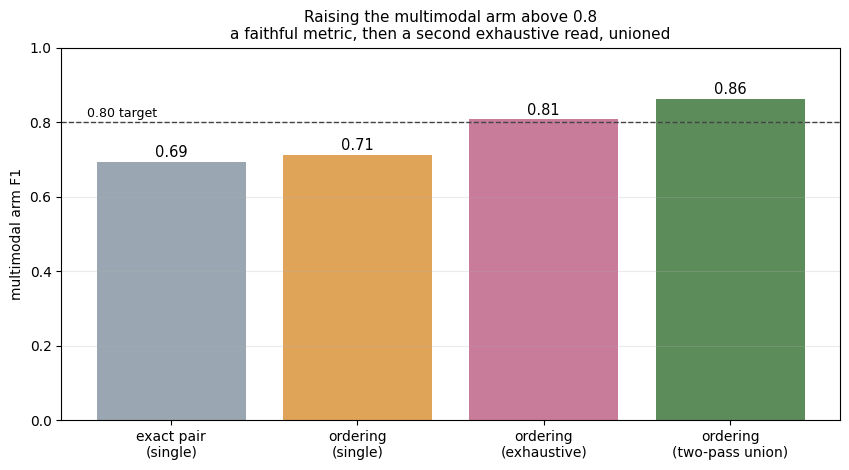

In [14]:
labels = ["exact pair\n(single)", "ordering\n(single)", "ordering\n(exhaustive)", "ordering\n(two-pass union)"]
vals = [exact_single, o_single[2], o_exhaust[2], o_union[2]]
colors = ["#9aa7b2", "#e0a458", "#c97b9a", "#5b8c5a"]
fig, ax = plt.subplots(figsize=(8.6, 4.8))
bars = ax.bar(labels, vals, color=colors)
ax.axhline(0.80, ls="--", color="#444", lw=1)
ax.text(-0.45, 0.815, "0.80 target", fontsize=9, ha="left")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f"{v:.2f}", ha="center", fontsize=10.5)
ax.set_ylim(0, 1.0); ax.set_ylabel("multimodal arm F1")
ax.set_title("Raising the multimodal arm above 0.8\na faithful metric, then a second exhaustive read, unioned", fontsize=11)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.savefig(f"{FIG}/m2b_climb.png", dpi=130, bbox_inches="tight"); plt.show()

The climb is honest, step by step. The first bar is the strict exact pair score, 0.69. Switching to ordering recovery on the same single read gives 0.71, a fairer metric rather than a better model. The exhaustive prompt as a second read brings 0.81, because the model writes down more of each paper's analytes and values. Unioning the two reads reaches 0.86, at recall 0.79 and precision 0.95. Nothing is tuned on the answers. The prompts are generic and the matching is deterministic, and precision stays at 0.95 while recall rises, so the extra recall is real reading, not guessing. The two papers still under 0.8, the scanned `jcej` and the dense gas phase `anie`, are the genuinely hard ones.

## Scale and audit

The recommended pipeline output is the two pass union. Pool its records into one table, drop duplicate pairs, and audit it before trusting it.

In [15]:
out, seen = [], set()
for hh in PAPERS:
    for r in extract(hh, "image") + extract(hh, "image_v2"):   # two pass union
        key = (hh, norm(r.get("target", "")), norm(r.get("interferent", "")))
        if key in seen:
            continue
        seen.add(key)
        c = r.get("condition", {}) or {}
        e = r.get("evidence", {}) or {}
        out.append(dict(doi=hh.replace("_", "/", 1), receptor=r.get("receptor", ""),
                        target=r.get("target", ""), interferent=r.get("interferent", ""),
                        solvent=c.get("solvent", ""), temperature=c.get("temperature", ""), pH=c.get("pH", ""),
                        readout_type=r.get("readout_type", ""), label_basis=r.get("label_basis", ""),
                        target_value=r.get("target_value", ""), interferent_value=r.get("interferent_value", ""),
                        figure_or_table=e.get("figure_or_table", "")))
ds = pd.DataFrame(out)
ds.to_csv("wetsensebench_multimodal_extracted.csv", index=False)

print(f"rows: {len(ds)}  from {ds.doi.nunique()} papers")
print(f"have a target value: {(ds.target_value.str.len() > 0).mean():.0%}")
print(f"cite a figure or table: {(ds.figure_or_table.str.len() > 0).mean():.0%}")
print(f"name a readout type: {(ds.readout_type.str.len() > 0).mean():.0%}")
ds.head(10)

rows: 211  from 8 papers
have a target value: 91%
cite a figure or table: 100%
name a readout type: 100%


,doi,receptor,target,interferent,solvent,temperature,pH,readout_type,label_basis,target_value,interferent_value,figure_or_table
0,10.1021/acs.joc.6b00267,TPEP,PA,NM,THF/water (10:90),not specified,not specified,fluorescence_quenching,quenching efficiency,,,Figure 6
1,10.1021/acs.joc.6b00267,TPEP,PA,NB,THF/water (10:90),not specified,not specified,fluorescence_quenching,quenching efficiency,,,Figure 6
2,10.1021/acs.joc.6b00267,TPEP,PA,NP,THF/water (10:90),not specified,not specified,fluorescence_quenching,quenching efficiency,,,Figure 6
3,10.1021/acs.joc.6b00267,TPEP,PA,DNP,THF/water (10:90),not specified,not specified,fluorescence_quenching,quenching efficiency,,,Figure 6
4,10.1021/acs.joc.6b00267,TPEP,PA,TNT,THF/water (10:90),not specified,not specified,fluorescence_quenching,quenching efficiency,,,Figure 6
5,10.1021/acs.joc.6b00267,TPEP,PA,Blank,THF/water (10:90),room temperature,N/A,relative fluorescence quenching,relative fluorescence quenching (%),strong,none,Figure 6
6,10.1021/acs.joc.6b00267,TPEP,TNT,DNP,THF/water (10:90),room temperature,N/A,relative fluorescence quenching,relative fluorescence quenching (%),moderate,medium,Figure 6
7,10.1021/acs.joc.6b00267,TPEP,TNT,NP,THF/water (10:90),room temperature,N/A,relative fluorescence quenching,relative fluorescence quenching (%),moderate,low,Figure 6
8,10.1021/acs.joc.6b00267,TPEP,TNT,NB,THF/water (10:90),room temperature,N/A,relative fluorescence quenching,relative fluorescence quenching (%),moderate,very low,Figure 6
9,10.1021/acs.joc.6b00267,TPEP,TNT,NM,THF/water (10:90),room temperature,N/A,relative fluorescence quenching,relative fluorescence quenching (%),moderate,negligible,Figure 6


## Limitations, stated plainly

- The gold is an expert curated reference from a multi agent pipeline with RDKit verification, not hand typed ground truth. Scores are relative to it.
- We rendered main text pages only. Some evidence lives in the SI, which caps recall for both arms on a few papers.
- The direction labels are skewed toward `target_favored`, so direction accuracy is near its ceiling and is reported only as a supporting check.
- `anie (CB6)` is a dense gas phase cross comparison paper and is the hardest case. Under exact pair match the image arm looks weak there; under ordering recovery with the two pass read it improves but stays the lowest of the eight. We kept it in rather than hide it.
- Name matching is a deterministic synonym map with isomer strict normalization. It is good, not perfect, and the synonym map is specific to this chemistry. An earlier LLM judge was dropped after it produced false matches on ambiguous abbreviations such as treating `PA` as the same as `TNT`.
- The ordering metric is the right measure when the gold curates its pairwise subset inconsistently across papers, which is the case here. Where a gold is a complete and uniform pairwise set, exact pair match is the stricter and better choice.

## Citation and reuse

Data and task adapted from WetSenseBench and the T3 text to data project (R. Ding et al.). Cite the corresponding work when you use this material.

To reuse this on your own papers: drop PDFs into `data/papers/`, render them with `pdftoppm -png -r 150` into `data/images/<id>/`, run `pdftotext` into `data/text/<id>.txt`, set `USE_CACHE = False` with an OpenRouter key, and call `extract(id, "image")`. The schema, the prompt, and the scoring code are the reusable parts.